# K-Nearest Neighbours from Scratch (Pure Python)
KNN classifier using Euclidean distance — no numpy in the core logic, no sklearn.
Dataset: Iris (4 features, 3 classes). Model saved to `../Models/knn_scratch.json`.

## 1. Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math, json, os
from collections import Counter
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris        = load_iris()
df          = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target']= iris.target
features    = list(iris.feature_names)
class_names = list(iris.target_names)

print(f"Shape: {df.shape}  |  Classes: {class_names}")
df.head(3)

Shape: (150, 5)  |  Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0


## 2. Train / Test Split (80/20, stratified)

In [2]:
X = df[features].values
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")

Train: 120  |  Test: 30


## 3. Feature Scaling (Z-Score)

KNN computes distances — a feature measured in large units will dominate
one measured in small units unless we standardise first.
**Always scale before KNN.**

In [3]:
# Fit on train only — no data leakage
col_mean = pd.DataFrame(X_train, columns=features).mean()
col_std  = pd.DataFrame(X_train, columns=features).std(ddof=1)

X_train_sc = ((pd.DataFrame(X_train, columns=features) - col_mean) / col_std).values
X_test_sc  = ((pd.DataFrame(X_test,  columns=features) - col_mean) / col_std).values

print(f"Scaled train mean ≈ {X_train_sc.mean(axis=0).round(10).tolist()}")

Scaled train mean ≈ [-0.0, 0.0, -0.0, 0.0]


## 4. KNN Theory

KNN is a **lazy learner** — it stores the entire training set and defers all
computation to prediction time.

**Euclidean distance** between point $x$ and training sample $x_i$:
$$d(x, x_i) = \sqrt{\sum_{j=1}^{p} (x_j - x_{ij})^2}$$

**Prediction:** find the $k$ training points closest to $x$, then:
$$\hat{y} = \text{majority class among } k \text{ nearest neighbours}$$

**Probability estimate:**
$$\hat{P}(y=c \mid x) = \frac{|\{i \in N_k(x) : y_i = c\}|}{k}$$

- Small $k$ → low bias, high variance (overfitting)
- Large $k$ → high bias, low variance (underfitting)
- $k = \sqrt{n}$ is a common starting heuristic

## 5. Core KNN Functions (Pure Python)

In [4]:
def euclidean(p1, p2):
    return math.sqrt(sum((a - b) ** 2 for a, b in zip(p1, p2)))

def manhattan(p1, p2):
    return sum(abs(a - b) for a, b in zip(p1, p2))


def knn_predict_one(x, X_tr, y_tr, k, metric='euclidean'):
    """
    Compute distances from x to every training point,
    find the k nearest, return the majority class label.
    """
    dist_fn  = euclidean if metric == 'euclidean' else manhattan
    dists    = [(dist_fn(x, X_tr[i]), y_tr[i]) for i in range(len(X_tr))]
    dists.sort(key=lambda t: t[0])
    k_labels = [label for _, label in dists[:k]]
    return Counter(k_labels).most_common(1)[0][0]


def knn_predict_proba_one(x, X_tr, y_tr, k, n_classes):
    """Return class probability vector from neighbour vote fractions."""
    dists    = [(euclidean(x, X_tr[i]), y_tr[i]) for i in range(len(X_tr))]
    dists.sort(key=lambda t: t[0])
    k_labels = [label for _, label in dists[:k]]
    counts   = Counter(k_labels)
    return [counts.get(c, 0) / k for c in range(n_classes)]


def knn_predict(X_test, X_train, y_train, k, metric='euclidean'):
    return [knn_predict_one(x, X_train, y_train, k, metric) for x in X_test]


def knn_predict_proba(X_test, X_train, y_train, k, n_classes):
    return [knn_predict_proba_one(x, X_train, y_train, k, n_classes) for x in X_test]

## 6. Predict & Evaluate (k=5)

In [5]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

K = 5
X_tr_list = X_train_sc.tolist()
X_te_list = X_test_sc.tolist()
y_tr_list = y_train.tolist()

y_pred  = knn_predict(X_te_list, X_tr_list, y_tr_list, k=K)
y_proba = knn_predict_proba(X_te_list, X_tr_list, y_tr_list, k=K, n_classes=len(class_names))
y_proba = np.array(y_proba)

print(f"k={K} | Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=class_names))

k=5 | Test Accuracy: 0.9333

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



## 7. Confusion Matrix

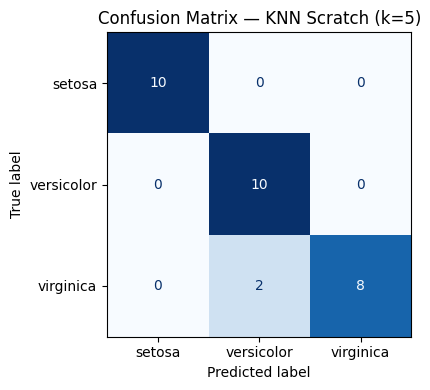

In [6]:
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — KNN Scratch (k={K})')
plt.tight_layout(); plt.show()

## 8. Effect of k on Accuracy

The bias-variance tradeoff is directly controlled by $k$.
We sweep $k = 1 \ldots 20$ to find the optimal value.

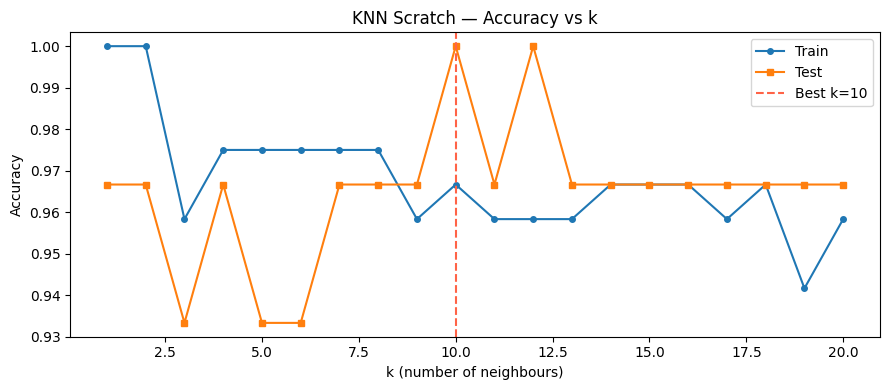

Best test accuracy: 1.0000 at k=10


In [7]:
k_range   = range(1, 21)
tr_accs   = []
te_accs   = []

for k in k_range:
    tr_pred = knn_predict(X_tr_list, X_tr_list, y_tr_list, k=k)
    te_pred = knn_predict(X_te_list, X_tr_list, y_tr_list, k=k)
    tr_accs.append(accuracy_score(y_train, tr_pred))
    te_accs.append(accuracy_score(y_test,  te_pred))

best_k   = list(k_range)[te_accs.index(max(te_accs))]

plt.figure(figsize=(9, 4))
plt.plot(k_range, tr_accs, marker='o', label='Train', markersize=4)
plt.plot(k_range, te_accs, marker='s', label='Test',  markersize=4)
plt.axvline(best_k, linestyle='--', color='tomato', label=f'Best k={best_k}')
plt.xlabel('k (number of neighbours)')
plt.ylabel('Accuracy')
plt.title('KNN Scratch — Accuracy vs k')
plt.legend(); plt.tight_layout(); plt.show()
print(f"Best test accuracy: {max(te_accs):.4f} at k={best_k}")

## 9. Euclidean vs Manhattan Distance

euclidean    | best k=10  acc=1.0000
manhattan    | best k=1  acc=0.9667


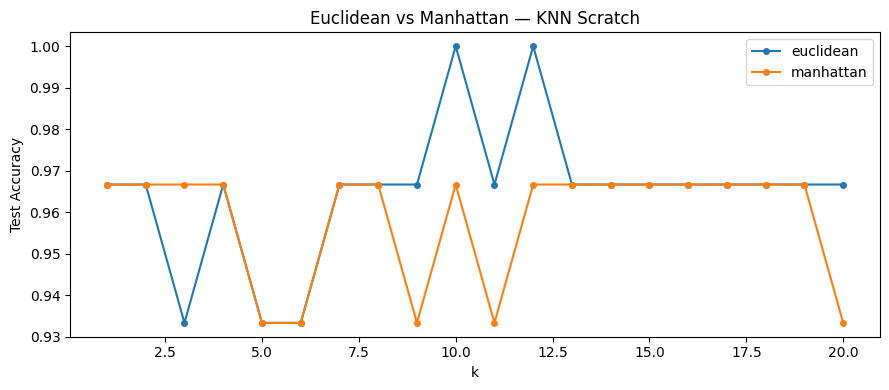

In [8]:
results = []
for metric in ['euclidean', 'manhattan']:
    accs = []
    for k in k_range:
        pred = knn_predict(X_te_list, X_tr_list, y_tr_list, k=k, metric=metric)
        accs.append(accuracy_score(y_test, pred))
    results.append((metric, accs))
    print(f"{metric:12s} | best k={list(k_range)[accs.index(max(accs))]}  acc={max(accs):.4f}")

plt.figure(figsize=(9, 4))
for metric, accs in results:
    plt.plot(k_range, accs, marker='o', markersize=4, label=metric)
plt.xlabel('k'); plt.ylabel('Test Accuracy')
plt.title('Euclidean vs Manhattan — KNN Scratch')
plt.legend(); plt.tight_layout(); plt.show()

## 10. Save Model to `../Models/`

In [9]:
model_data = {
    'k':            K,
    'feature_names':features,
    'class_names':  class_names,
    'col_mean':     col_mean.tolist(),
    'col_std':      col_std.tolist(),
    'X_train':      X_train_sc.tolist(),    # scaled training data
    'y_train':      y_train.tolist(),
    'split':        {'test_size': 0.2, 'random_state': 42, 'stratify': True}
}

save_path = '../Models/knn_scratch.json'
with open(save_path, 'w') as f:
    json.dump(model_data, f)

size_kb = os.path.getsize(save_path) / 1024
print(f"Saved → {save_path}  ({size_kb:.1f} KB)")

Saved → ../Models/knn_scratch.json  (10.6 KB)
